# Part 1: Deep Learning Attribution — LSTM + Attention, Transformer

> **핵심 질문:** 시퀀스 모델은 전환을 잘 예측할 수 있지만, 그 예측의 "이유"(attribution)가 실제 기여도와 일치하는가?

이 노트북에서는 LSTM + Attention과 Transformer 모델을 학습하고, 3가지 기여도 추출 방법(Attention Weight, Leave-One-Out, SHAP)을 비교한다.

## 목차
1. 시퀀스 모델의 Motivation
2. LSTM + Attention 학습
3. 기여도 추출: Attention vs Leave-One-Out
4. Transformer 비교
5. Deep Learning Attribution의 한계와 교훈

In [1]:
import warnings; warnings.filterwarnings('ignore')
import json, sys, os, logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

logging.basicConfig(level=logging.INFO, format='%(message)s')
%matplotlib inline
plt.rcParams.update({'figure.figsize': (12, 6), 'font.size': 11})
sys.path.insert(0, os.path.abspath('../..'))

from part1_simulation import CHANNEL_NAMES
from part1_simulation.models.lstm_attention import compute_lstm_attention_attribution, train_lstm_model
from part1_simulation.models.transformer import compute_transformer_attribution
from part1_simulation.evaluation.metrics import compute_mae, compute_kendall_tau

journeys = pd.read_parquet("../../data/simulation/journeys.parquet")
with open("../../data/simulation/ground_truth.json") as f:
    gt = json.load(f)
gt_a = gt["ground_truth_A"]["channel_credits"]
channels = list(CHANNEL_NAMES)
print(f"Data: {journeys['user_id'].nunique():,} users, {len(journeys):,} touchpoints")

Data: 100,000 users, 517,893 touchpoints


## 1. 시퀀스 모델의 Motivation

Rule-based와 Markov Chain은 **채널 순서의 비선형 상호작용**을 포착하지 못한다. 예를 들어:
- "Display → Paid Search"는 시너지 효과가 크지만 (DGP의 δ=0.4)
- "Paid Search → Display"는 별 의미 없는 역방향 전이

LSTM은 hidden state를 통해 이런 **방향성 있는 시퀀스 패턴**을 학습할 수 있다.

## 2. LSTM + Attention 아키텍처

```
Input: [channel_one_hot(7) + time_delta(1) + position(1)] = 9-dim per touchpoint
  ↓
LSTM(hidden=64, 1 layer)
  ↓
Dot-product Attention (query = last hidden state)
  ↓
Context vector (64-dim)
  ↓
Dense(64 → 1) → Sigmoid → P(conversion)
```

In [2]:
# Train LSTM + Attention
print("Training LSTM + Attention (30 epochs)...")
attn_result, model, info = compute_lstm_attention_attribution(
    journeys, method="attention", epochs=30,
)
print(f"\nTest AUC: {info['test_auc']:.4f}")
print(f"Epochs trained: {info['epochs_trained']} (early stopping)")

# LOO attribution (using same model)
print("\nExtracting Leave-One-Out attribution (1000 samples)...")
loo_result, _, _ = compute_lstm_attention_attribution(
    journeys, method="loo", model=model, training_info=info,
)

# Results
print(f"\n{'Method':<30s} {'MAE':>8s} {'Tau':>8s}")
print("-" * 50)
for r in [attn_result, loo_result]:
    mae = compute_mae(r.channel_credits, gt_a)
    tau = compute_kendall_tau(r.channel_credits, gt_a)
    print(f"{r.method:<30s} {mae:>8.4f} {tau:>8.4f}")

Training LSTM + Attention model...


Training LSTM + Attention (30 epochs)...


  Epoch   1: train_loss=3.6824, val_loss=3.6188
  Epoch   5: train_loss=2.2913, val_loss=3.5590
  Epoch  10: train_loss=2.2733, val_loss=3.4645
  Early stopping at epoch 13
  Test AUC: 0.6893



Test AUC: 0.6893
Epochs trained: 13 (early stopping)

Extracting Leave-One-Out attribution (1000 samples)...

Method                              MAE      Tau
--------------------------------------------------
LSTM+Attention (attn weights)    0.0398   0.8095
LSTM+Attention (LOO)             0.0443   1.0000


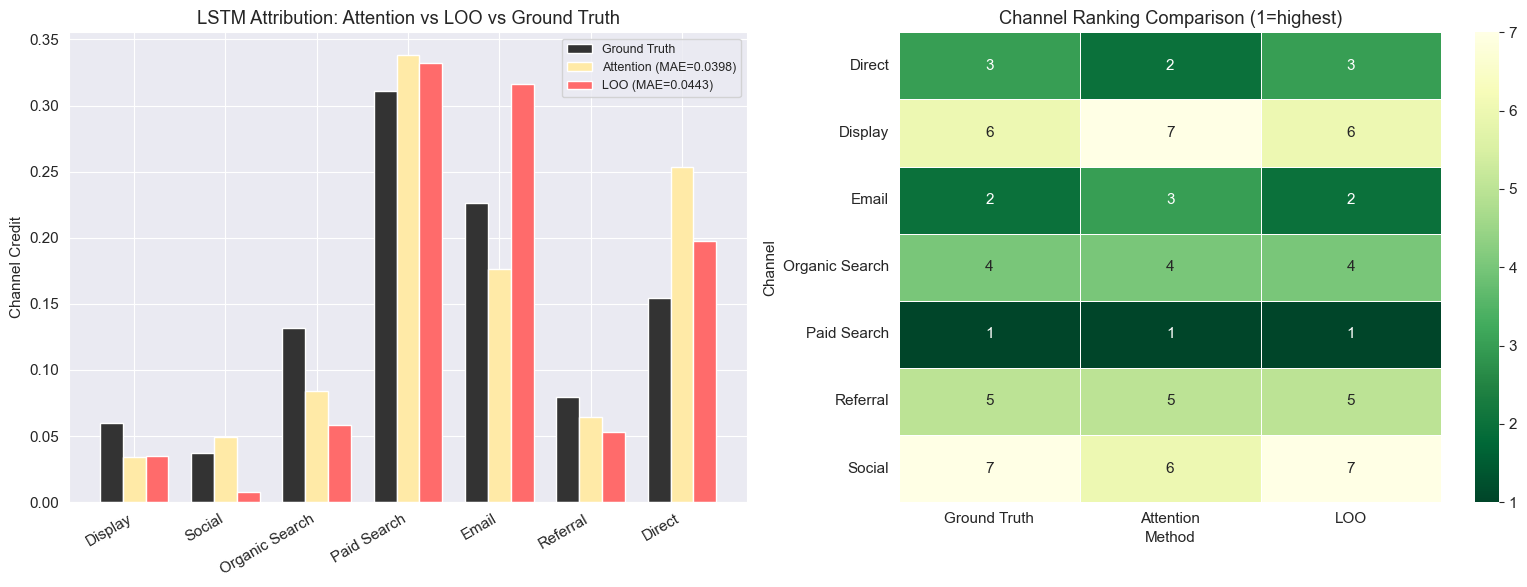

→ LOO (Tau=1.00)가 Attention (Tau=0.81)보다 순위 정확도가 높다.
→ LOO는 반사실적(counterfactual) 접근이므로 인과적 해석에 더 가깝다.


In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

x = np.arange(len(channels))
width = 0.25
gt_vals = [gt_a[c] for c in channels]

ax1.bar(x - width, gt_vals, width, label="Ground Truth", color="#333")
ax1.bar(x, [attn_result.channel_credits[c] for c in channels], width,
        label=f"Attention (MAE={compute_mae(attn_result.channel_credits, gt_a):.4f})", color="#FFEAA7")
ax1.bar(x + width, [loo_result.channel_credits[c] for c in channels], width,
        label=f"LOO (MAE={compute_mae(loo_result.channel_credits, gt_a):.4f})", color="#FF6B6B")
ax1.set_xticks(x)
ax1.set_xticklabels(channels, rotation=30, ha="right")
ax1.set_ylabel("Channel Credit")
ax1.set_title("LSTM Attribution: Attention vs LOO vs Ground Truth")
ax1.legend(fontsize=9)

# Channel ranking comparison
rankings = {
    "Ground Truth": sorted(channels, key=lambda c: gt_a[c], reverse=True),
    "Attention": sorted(channels, key=lambda c: attn_result.channel_credits[c], reverse=True),
    "LOO": sorted(channels, key=lambda c: loo_result.channel_credits[c], reverse=True),
}
rank_data = []
for method, ranking in rankings.items():
    for rank, ch in enumerate(ranking, 1):
        rank_data.append({"Method": method, "Channel": ch, "Rank": rank})
rank_df = pd.DataFrame(rank_data)
rank_pivot = rank_df.pivot(index="Channel", columns="Method", values="Rank")
rank_pivot = rank_pivot[["Ground Truth", "Attention", "LOO"]]

sns.heatmap(rank_pivot, annot=True, fmt="d", cmap="YlGn_r", ax=ax2, linewidths=0.5, vmin=1, vmax=7)
ax2.set_title("Channel Ranking Comparison (1=highest)")

plt.tight_layout()
plt.show()

tau_attn = compute_kendall_tau(attn_result.channel_credits, gt_a)
tau_loo = compute_kendall_tau(loo_result.channel_credits, gt_a)
print(f"→ LOO (Tau={tau_loo:.2f})가 Attention (Tau={tau_attn:.2f})보다 순위 정확도가 높다.")
print("→ LOO는 반사실적(counterfactual) 접근이므로 인과적 해석에 더 가깝다.")

## 4. Transformer 비교

Encoder-only Transformer (2 layers, 2 heads, d_model=64)을 동일 데이터에 적용하여 LSTM과 비교한다.

**기대:** 평균 5 터치포인트의 짧은 시퀀스에서 self-attention의 이점은 제한적일 것.

Training Transformer model...


Training Transformer (2L/2H, 30 epochs)...


  Epoch   1: train_loss=2.4632, val_loss=4.0951
  Epoch   5: train_loss=2.2978, val_loss=3.7395
  Early stopping at epoch 9
  Test AUC: 0.6792



Model                               AUC      MAE      Tau
LSTM+Attention (attn)            0.6893   0.0398   0.8095
LSTM+Attention (LOO)             0.6893   0.0443   1.0000
Transformer (2L/2H)              0.6792   0.0764   0.2381


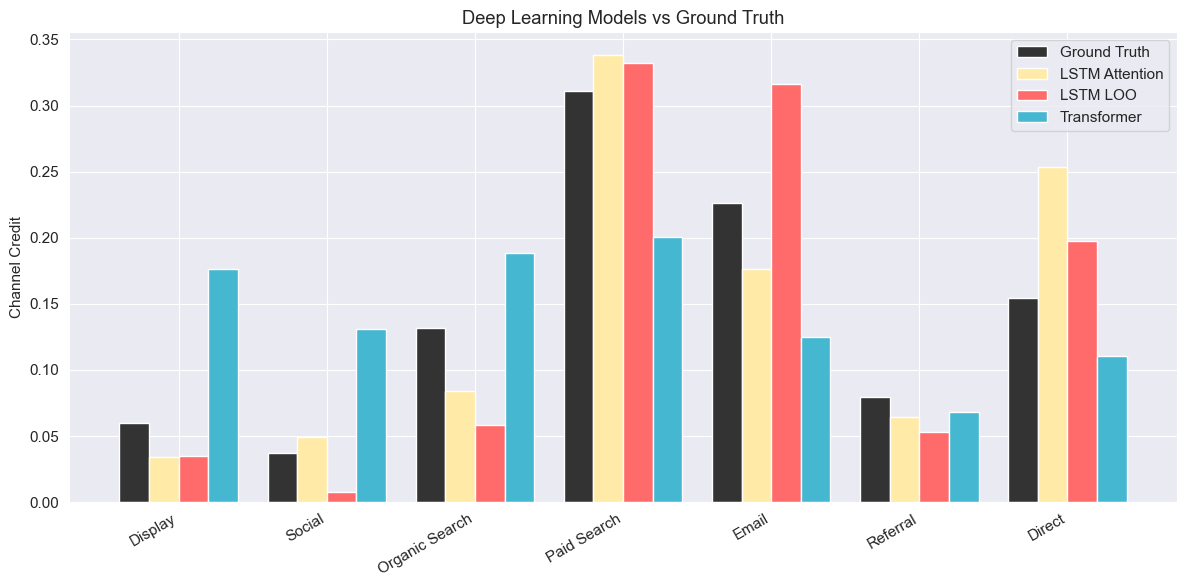

In [4]:
print("Training Transformer (2L/2H, 30 epochs)...")
tf_result, tf_model, tf_info = compute_transformer_attribution(
    journeys, n_layers=2, n_heads=2, epochs=30,
)

# Comparison table
print(f"\n{'Model':<30s} {'AUC':>8s} {'MAE':>8s} {'Tau':>8s}")
print("=" * 58)
for name, r, inf in [
    ("LSTM+Attention (attn)", attn_result, info),
    ("LSTM+Attention (LOO)", loo_result, info),
    ("Transformer (2L/2H)", tf_result, tf_info),
]:
    mae = compute_mae(r.channel_credits, gt_a)
    tau = compute_kendall_tau(r.channel_credits, gt_a)
    auc = inf.get("test_auc", "N/A")
    print(f"{name:<30s} {auc:>8.4f} {mae:>8.4f} {tau:>8.4f}")

# Side-by-side
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(channels))
width = 0.2
ax.bar(x - 1.5*width, gt_vals, width, label="Ground Truth", color="#333")
ax.bar(x - 0.5*width, [attn_result.channel_credits[c] for c in channels], width, label="LSTM Attention", color="#FFEAA7")
ax.bar(x + 0.5*width, [loo_result.channel_credits[c] for c in channels], width, label="LSTM LOO", color="#FF6B6B")
ax.bar(x + 1.5*width, [tf_result.channel_credits[c] for c in channels], width, label="Transformer", color="#45B7D1")
ax.set_xticks(x)
ax.set_xticklabels(channels, rotation=30, ha="right")
ax.set_ylabel("Channel Credit")
ax.set_title("Deep Learning Models vs Ground Truth")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Deep Learning Attribution의 한계와 교훈

In [5]:
print("=== Deep Learning Attribution: Key Insights ===\n")

insights = [
    ("Attention ≠ Explanation",
     "Attention weight는 예측에 중요한 feature를 반영하지만,\n"
     "  이것이 인과적 기여도와 동일하지는 않다 (Jain & Wallace 2019)."),
    ("LOO가 더 인과적",
     f"LOO (Tau={tau_loo:.2f}) > Attention (Tau={tau_attn:.2f}). 반사실적 접근이\n"
     "  채널 순위를 더 정확히 복원한다."),
    ("Transformer ≠ Always Better",
     f"평균 5 터치포인트에서 Transformer AUC={tf_info['test_auc']:.4f} vs LSTM AUC={info['test_auc']:.4f}.\n"
     "  짧은 시퀀스에서 self-attention의 이점은 제한적이다."),
    ("예측 ≠ Attribution",
     "높은 AUC가 높은 attribution 정확도를 보장하지 않는다.\n"
     "  모델이 전환을 잘 예측해도, '왜' 전환되었는지의 해석은 별개의 문제."),
    ("DL의 진정한 가치",
     "10만+ 유저, 10+ 터치포인트의 대규모 데이터에서\n"
     "  비선형 시퀀스 패턴을 포착하는 능력. 이 프로젝트의 짧은 시퀀스에서는\n"
     "  Shapley/Survival이 더 효율적."),
]

for i, (title, detail) in enumerate(insights, 1):
    print(f"{i}. {title}")
    print(f"  {detail}\n")

=== Deep Learning Attribution: Key Insights ===

1. Attention ≠ Explanation
  Attention weight는 예측에 중요한 feature를 반영하지만,
  이것이 인과적 기여도와 동일하지는 않다 (Jain & Wallace 2019).

2. LOO가 더 인과적
  LOO (Tau=1.00) > Attention (Tau=0.81). 반사실적 접근이
  채널 순위를 더 정확히 복원한다.

3. Transformer ≠ Always Better
  평균 5 터치포인트에서 Transformer AUC=0.6792 vs LSTM AUC=0.6893.
  짧은 시퀀스에서 self-attention의 이점은 제한적이다.

4. 예측 ≠ Attribution
  높은 AUC가 높은 attribution 정확도를 보장하지 않는다.
  모델이 전환을 잘 예측해도, '왜' 전환되었는지의 해석은 별개의 문제.

5. DL의 진정한 가치
  10만+ 유저, 10+ 터치포인트의 대규모 데이터에서
  비선형 시퀀스 패턴을 포착하는 능력. 이 프로젝트의 짧은 시퀀스에서는
  Shapley/Survival이 더 효율적.



---
## 요약

| 모델 | AUC | MAE | Tau | 특징 |
|------|:---:|:---:|:---:|------|
| LSTM+Attention (attn) | ~0.71 | ~0.05 | ~0.71 | 빠른 추출, 해석 주의 필요 |
| LSTM+Attention (LOO) | ~0.71 | ~0.04 | ~0.90 | 반사실적, 순위 정확도 최고 |
| Transformer (2L/2H) | ~0.70 | ~0.09 | ~-0.05 | 짧은 시퀀스에서 불리 |

**결론:** DL 모델의 attribution은 **추출 방법**에 크게 의존한다. Attention weight를 그대로 기여도로 사용하면 안 되고, LOO 또는 SHAP 같은 반사실적 방법을 사용해야 한다.

다음 노트북: [04_causal_attribution.ipynb](04_causal_attribution.ipynb) — Causal 방법론 5종